In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, classification_report, f1_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Prefer ThunderSVM for GPU acceleration if available
try:
    from thundersvm import SVC as TSVC
    _HAVE_TSV = True
except Exception:
    TSVC = None
    _HAVE_TSV = False


In [2]:
import joblib

In [108]:
# Optional GPU-accelerated logistic regression via skorch (PyTorch)
try:
    import torch
    import torch.nn as nn
    from skorch import NeuralNetBinaryClassifier
    _HAVE_SKORCH = True
    _TORCH_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    class TorchLogisticRegression(nn.Module):
        def __init__(self, input_dim: int = 4096):
            super().__init__()
            self.linear = nn.Linear(input_dim, 1)
        def forward(self, X):
            logits = self.linear(X)
            return logits.view(-1)
except Exception:
    _HAVE_SKORCH = False
    NeuralNetBinaryClassifier = None
    TorchLogisticRegression = None
    _TORCH_DEVICE = 'cpu'


In [ ]:


def train_linear_probe(
    X: np.ndarray,
    y: np.ndarray,
    model_type: str = "logreg",  # "logreg" or "svm"
    test_size: float = 0.2,
    random_state: int = 42,
    do_calibrate: bool = True,   # for SVM to get calibrated probabilities
    backend: str = "sklearn",    # for logreg: "sklearn" or "skorch"
    class_weight: "str|dict|None" = "balanced",  # class weighting
    uids: Optional[np.ndarray] = None,
):
    assert model_type in {"logreg", "svm"}
    if model_type == "logreg":
        assert backend in {"sklearn", "skorch"}
    X = np.asarray(X)
    y = np.asarray(y).astype(int)
    if X.ndim != 2 or X.shape[1] != 4096:
        raise ValueError(f"Expected X shape (n_samples, 4096); got {X.shape}")
    if set(np.unique(y)) - {0, 1}:
        raise ValueError("y must be binary labels {0,1}")

    # Use an index-based split to keep alignment for optional uids
    all_idx = np.arange(X.shape[0])
    train_idx, test_idx = train_test_split(
        all_idx, test_size=test_size, stratify=y, random_state=random_state
    )
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    if model_type == "logreg" and backend == "sklearn":
        # Logistic Regression with L1/L2 via saga; handles imbalance
        pipe = Pipeline(steps=[
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("clf", LogisticRegression(
                solver="saga",
                penalty="l2",   # will be tuned
                max_iter=3000,
                class_weight=class_weight,
                n_jobs=None,    # keep None for compatibility
                random_state=random_state
            ))
        ])
        param_grid = {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
            "clf__penalty": ["l1", "l2"]
        }
        needs_calibration = False

    elif model_type == "logreg" and backend == "skorch":
        if not _HAVE_SKORCH:
            raise ImportError("skorch is not installed or PyTorch unavailable. Install with `pip install skorch torch`.")
        # Compute class imbalance for BCEWithLogitsLoss pos_weight according to class_weight
        num_pos = max(int((y_train == 1).sum()), 1)
        num_neg = max(int((y_train == 0).sum()), 1)
        if class_weight == "balanced":
            pos_weight_val = num_neg / num_pos
        elif isinstance(class_weight, dict):
            w0 = float(class_weight.get(0, 1.0))
            w1 = float(class_weight.get(1, 1.0))
            pos_weight_val = w1 / max(w0, 1e-12)
        else:
            pos_weight_val = 1.0
        # Define skorch net
        net = NeuralNetBinaryClassifier(
            module=TorchLogisticRegression,
            module__input_dim=4096,
            criterion=nn.BCEWithLogitsLoss,
            criterion__pos_weight=torch.tensor(pos_weight_val, device=_TORCH_DEVICE, dtype=torch.float32),
            optimizer=torch.optim.Adam,
            lr=1e-3,
            max_epochs=40,
            batch_size=256,
            train_split=None,  # CV will handle validation
            device=_TORCH_DEVICE,
            verbose=0,
        )
        pipe = Pipeline(steps=[
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("clf", net),
        ])
        param_grid = {
            "clf__lr": [1e-3, 3e-3, 1e-2],
            "clf__max_epochs": [30, 60],
            "clf__optimizer__weight_decay": [0.0, 1e-4, 1e-3],
            # Optionally tune batch_size: "clf__batch_size": [128, 256]
        }
        needs_calibration = False

    else:  # "svm"
        # Linear SVM with ThunderSVM; enable probabilities via calibration
        if TSVC is None:
            raise ImportError("ThunderSVM (thundersvm) is not installed. Please `pip install thundersvm` (or thundersvm-cpu) and ensure CUDA for GPU.")
        pipe = Pipeline(steps=[
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("clf", TSVC(
                kernel="linear",
                C=1.0,
                probability=False  # we'll use external calibration
            ))
        ])
        param_grid = {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
        }
        needs_calibration = True
        # Emulate class_weight for SVM via sample_weight (if needed) when calling fit
        fit_kwargs = {}
        if class_weight == "balanced":
            # per-sample weights inversely proportional to class frequency
            n1 = max(int((y_train == 1).sum()), 1)
            n0 = max(int((y_train == 0).sum()), 1)
            w1 = 0.5 / n1
            w0 = 0.5 / n0
            sample_weight = np.where(y_train == 1, w1, w0).astype(np.float32)
            fit_kwargs = {"clf__sample_weight": sample_weight}
        elif isinstance(class_weight, dict):
            w0 = float(class_weight.get(0, 1.0))
            w1 = float(class_weight.get(1, 1.0))
            sample_weight = np.where(y_train == 1, w1, w0).astype(np.float32)
            fit_kwargs = {"clf__sample_weight": sample_weight}
        else:
            fit_kwargs = {}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
        return_train_score=True,
    )
    # Ensure correct target dtype for skorch (BCEWithLogitsLoss expects float targets)
    y_train_fit = y_train.astype(np.float32) if (model_type == "logreg" and backend == "skorch") else y_train
    # Pass sample weights if set (for SVM weighting)
    try:
        grid.fit(X_train, y_train_fit, **(fit_kwargs if 'fit_kwargs' in locals() else {}))
    except TypeError:
        grid.fit(X_train, y_train_fit)

    best_model = grid.best_estimator_

    # Optionally calibrate SVM for probabilities
    calibrated_model = None
    if model_type == "svm" and do_calibrate:
        calibrated_model = CalibratedClassifierCV(
            estimator=best_model,
            method="sigmoid",
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        )
        calibrated_model.fit(X_train, y_train)

    # Evaluate on test
    def get_scores(model, X_eval):
        # Prefer predict_proba; else decision_function; else fallback to predictions
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_eval)
            if proba.ndim == 1:
                probs = proba.astype(float)
            elif proba.shape[1] == 2:
                probs = proba[:, 1]
            else:
                probs = proba[:, -1]
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_eval)
            smin, smax = scores.min(), scores.max()
            probs = (scores - smin) / (smax - smin + 1e-12)
        else:
            probs = model.predict(X_eval).astype(float)
        preds = (probs >= 0.5).astype(int)
        return probs, preds

    model_for_eval = calibrated_model if calibrated_model is not None else best_model
    probs_test, preds_test = get_scores(model_for_eval, X_test)

    # Train-set scores
    probs_train, preds_train = get_scores(model_for_eval, X_train)
    # For skorch, ensure preds are computed against float targets; metrics use integer y

    # Attach uids if provided
    uids_out = None
    if uids is not None:
        uids = np.asarray(uids)
        # Align to the current split using the index masks
        if uids.shape[0] == X.shape[0]:
            uids_train = uids[train_idx]
            uids_test = uids[test_idx]
        else:
            uids_train = None
            uids_test = None
        uids_out = {"train": uids_train, "test": uids_test}

    # Extract classification plane w, b in input space
    plane = None
    try:
        # handle pipeline: scaler then classifier
        scaler = best_model.named_steps.get("scaler")
        clf = (calibrated_model if calibrated_model is not None else best_model).named_steps.get("clf")
        # get raw classifier for coef_/dual_coef_
        raw_clf = clf
        if hasattr(raw_clf, "module_"):
            w_vec = raw_clf.module_.linear.weight.detach().cpu().numpy().reshape(-1)
            b_val = float(raw_clf.module_.linear.bias.detach().cpu().numpy().reshape(-1)[0])
        elif hasattr(raw_clf, "coef_"):
            w_vec = raw_clf.coef_.reshape(-1)
            b_val = float(getattr(raw_clf, "intercept_", np.array([0.0])).reshape(-1)[0])
        else:
            w_vec = None
            b_val = None
        if w_vec is not None and scaler is not None:
            # map from standardized space back to original: w = w_s / std, b = b_s - w^T(mu/std)
            std = scaler.scale_.astype(float)
            mean = scaler.mean_.astype(float)
            w_orig = w_vec / (std + 1e-12)
            b_orig = b_val - float(np.dot(w_vec, mean / (std + 1e-12)))
            plane = {"w": w_orig, "b": b_orig}
    except Exception:
        plane = None

    # 2D projection in subspace orthogonal to w
    projection = None
    try:
        if plane is not None:
            w = plane["w"].astype(float)
            b = float(plane["b"])
            w_norm = w / (np.linalg.norm(w) + 1e-12)
            # project X to w-perp and run PCA(2)
            X_center = X - X.mean(axis=0, keepdims=True)
            X_ortho = X_center - (X_center @ w_norm[:, None]) * w_norm[None, :]
            pca = PCA(n_components=2, random_state=random_state)
            Z2 = pca.fit_transform(X_ortho)
            # Plot projection with points
            plt.figure(figsize=(7, 6))
            cmap = plt.get_cmap("coolwarm")
            plt.scatter(Z2[:, 0], Z2[:, 1], c=y, cmap=cmap, s=10, alpha=0.7)
            plt.title("2D projection (orthogonal to classification plane)")
            plt.xlabel("PC1 in w⊥")
            plt.ylabel("PC2 in w⊥")
            # Overlay the plane's decision boundary as w·x + b = 0 -> in w⊥, boundary is a single point (projection of origin onto w⊥).
            # To give a visible reference, draw margin vs PC1 plot separately below.
            plt.tight_layout()
            plt.savefig("projection_w_perp.png", dpi=160)
            plt.close()
            projection = {"Z2": Z2, "pca": pca}
            # Additional plot: margin vs PC1_perp with decision boundary at 0
            margin = (X @ w + b)
            pc1 = Z2[:, 0]
            plt.figure(figsize=(7, 5))
            plt.scatter(pc1, margin, c=y, cmap=cmap, s=10, alpha=0.7)
            plt.axhline(0.0, color="k", linestyle="--", linewidth=1.0, label="decision boundary")
            plt.xlabel("PC1 in w⊥")
            plt.ylabel("Margin w⋅x+b")
            plt.legend(loc="best")
            plt.tight_layout()
            plt.savefig("projection_margin_vs_pc1.png", dpi=160)
            plt.close()
    except Exception:
        projection = None

    metrics = {
        "train_accuracy": float(accuracy_score(y_train, preds_train)),
        "test_accuracy": float(accuracy_score(y_test, preds_test)),
        "train_f1": float(f1_score(y_train, preds_train)),
        "test_f1": float(f1_score(y_test, preds_test)),
        "roc_auc": float(roc_auc_score(y_test, probs_test)),
        "average_precision": float(average_precision_score(y_test, probs_test)),
        "best_params": grid.best_params_,
        "best_cv_score": float(grid.best_score_),
        "calibrated": bool(calibrated_model is not None),
        "model_type": model_type,
        "scoring": "f1",
    }

    print(f"Best params: {grid.best_params_}")
    print(f"Best CV F1: {metrics['best_cv_score']:.4f}")
    print(f"Calibrated: {metrics['calibrated']}")
    print(f"Train Acc: {metrics['train_accuracy']:.4f}  Train F1: {metrics['train_f1']:.4f}")
    print(f"Test  Acc: {metrics['test_accuracy']:.4f}  Test  F1: {metrics['test_f1']:.4f}")
    print(f"Test ROC-AUC: {metrics['roc_auc']:.4f}  AP: {metrics['average_precision']:.4f}")
    print("Classification report (test):")
    print(classification_report(y_test, preds_test, digits=4))

    # Build and save CV results table for F1 (train/test means)
    try:
        cvres = pd.DataFrame(grid.cv_results_)
        cols = [c for c in cvres.columns if c.startswith('param_')] + [
            'mean_train_score', 'std_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score'
        ]
        table = cvres[cols].sort_values('rank_test_score')
        table.to_csv('cv_f1_table.csv', index=False)
        print("Saved cross-validation F1 table to cv_f1_table.csv")
        # Also print top 10
        print(table.head(10).to_string(index=False))
    except Exception as e:
        print(f"Could not build CV table: {e}")

    # Save the final model and artifacts
    final_model = model_for_eval
    joblib.dump(final_model, "linear_probe.joblib")
    if plane is not None:
        np.savez("classification_plane.npz", w=plane["w"], b=plane["b"])
    if projection is not None:
        np.save("projection_w_perp.npy", projection["Z2"]) 
    print("Saved model to linear_probe.joblib")

    return final_model, metrics, (X_test, y_test, probs_test, preds_test), plane, projection, uids_out


In [440]:
import math
from typing import Optional, Dict, Any

def plot_margin_vs_pc1_perp(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    b: float = 0.0,
    *,
    center: bool = True,
    random_state: int = 42,
    hue: Optional[np.ndarray] = None,
    class_names: Optional[Dict[int, str]] = None,
    hue_names: Optional[Dict[Any, str]] = None,
    cmap: str = "coolwarm",
    figsize: tuple = (7, 5),
    savepath: Optional[str] = None,
    ax: Optional[Any] = None,
    uids: Optional[np.ndarray] = None,
    return_data: bool = False,
):
    """
    Plot margin versus the first principal direction orthogonal to a learned linear decision plane.

    The setting: a linear classifier in R^d is defined by a normal direction w and bias b, with decision
    function f(x) = w^T x + b. The hyperplane {x | f(x) = 0} partitions R^d into two half-spaces, and the
    signed distance to the hyperplane (up to scaling) is precisely the margin m(x) = w^T x + b.

    Goal of the visualization: rather than projecting the data directly onto the decision direction w (which
    collapses all structure to a single scalar), we examine the geometry *orthogonal* to w. We remove the
    component of x along w (i.e., project into w^\perp), then compute the 1D principal direction (PC1) inside
    that subspace: this captures the dominant variance in the degrees of freedom that do not affect the decision
    boundary. We then plot the pair (PC1_\perp(x), margin(x)). Key properties:

    - The y-axis (margin) measures how confidently the classifier separates samples. The decision boundary is the
      horizontal line m(x) = 0. Points far from this line have larger magnitude margins and are typically more
      confidently classified (under linear models, this relates to robustness of the decision under small
      perturbations).
    - The x-axis (PC1 in w^\perp) reveals the most significant variation in data that does not directly change the
      classification (to first order). This helps diagnose structure (e.g., clusters, difficulty modes) that the
      classifier is *invariant* to.
    - Because all points are shown with their true labels (and optional hue groups like difficulty), one can spot
      systematic patterns in misclassifications (e.g., certain difficulties concentrate near small margins).

    Inputs:
    - X: array of shape (n_samples, d), hidden vectors in the same space the classifier operates on.
    - y: array of shape (n_samples,), ground-truth binary labels in {0,1} (used for coloring and legend).
    - w, b: classifier parameters in input space (e.g., recovered from a standardized pipeline by rescaling).

    What the plot shows:
    - Scatter of points colored by y (or an optional hue). The horizontal dashed line at 0 marks the decision boundary.
    - The x-axis is the first principal component inside w^\perp; the y-axis is the margin w^T x + b.

    Suggested uses:
    - Group by problem difficulty via the `hue` argument to study how difficulty relates to margin and invariant
      variability.
    - Use this alongside confusion or calibration analysis to interpret where errors occur in representation space.

    Returns (if return_data=True): a dict containing {"pc1": pc1, "margin": margin, "indices": np.arange(n)}.
    """
    X = np.asarray(X)
    y = np.asarray(y).astype(int)
    w = np.asarray(w).astype(float)
    assert X.ndim == 2 and w.ndim == 1 and X.shape[1] == w.shape[0], "X shape and w length must agree"

    # Compute margins
    margin = (X @ w) + float(b)

    # Project to w^perp and take 1D PCA within that subspace
    w_norm = w / (np.linalg.norm(w) + 1e-12)
    X_center = X - (X.mean(axis=0, keepdims=True) if center else 0.0)
    X_ortho = X_center - (X_center @ w_norm[:, None]) * w_norm[None, :]
    pca = PCA(n_components=1, random_state=random_state)
    pc1 = pca.fit_transform(X_ortho).reshape(-1)

    # Prepare plotting
    import matplotlib as mpl
    fig, ax = (None, ax) if ax is not None else (plt.figure(figsize=figsize), plt.gca())
    cmap_obj = plt.get_cmap(cmap)

    # Determine coloring scheme
    if hue is None:
        # Use numeric classes as colors with provided cmap for robustness
        cvals = (y == 1).astype(int)
        scatter = ax.scatter(pc1, margin, c=cvals, cmap=cmap_obj, s=12, alpha=0.75, edgecolors="none")
        # Build legend for labels
        class_names = class_names or {0: "Class 0", 1: "Class 1"}
        proxy0 = mpl.lines.Line2D([0], [0], marker='o', color='w', label=class_names.get(0, '0'),
                                  markerfacecolor=cmap_obj(0.15), markersize=7)
        proxy1 = mpl.lines.Line2D([0], [0], marker='o', color='w', label=class_names.get(1, '1'),
                                  markerfacecolor=cmap_obj(0.85), markersize=7)
        ax.legend(handles=[proxy0, proxy1], title="Label", loc="best", frameon=True)
    else:
        hue = np.asarray(hue)
        # Map discrete hue values to distinct colors
        unique_vals = pd.unique(hue)
        norm = mpl.colors.Normalize(vmin=0, vmax=max(len(unique_vals)-1, 1))
        col_map = {val: cmap_obj(norm(i)) for i, val in enumerate(unique_vals)}
        colors = np.array([col_map[v] for v in hue])
        scatter = ax.scatter(pc1, margin, c=colors, s=12, alpha=0.75, edgecolors="none")
        # Legend for hue groups
        hue_names = hue_names or {}
        proxies = [mpl.lines.Line2D([0],[0], marker='o', color='w', markerfacecolor=col_map[val],
                                    markersize=7, label=hue_names.get(val, str(val)))
                   for val in unique_vals]
        ax.legend(handles=proxies, title="Group", loc="best", frameon=True)

    # Decision boundary line at margin=0
    ax.axhline(0.0, color="k", linestyle="--", linewidth=1.0, label="decision boundary")

    ax.set_xlabel("PC1 in w⊥")
    ax.set_ylabel("Margin w⋅x+b")
    ax.set_title("Margin vs PC1 in w⊥")
    ax.grid(True, alpha=0.2)

    if savepath:
        fig = ax.figure
        fig.tight_layout()
        fig.savefig(savepath, dpi=160)

    if return_data:
        return {"pc1": pc1, "margin": margin, "indices": np.arange(X.shape[0]), "uids": (None if uids is None else np.asarray(uids))}
    return ax


def get_misclassified_examples(
    model: Any,
    X: np.ndarray,
    y: np.ndarray,
    meta_df: Optional[pd.DataFrame] = None,
    *,
    columns: Optional[list] = None,
    include_gold: bool = True,
    uids: Optional[np.ndarray] = None,
    top_k: Optional[int] = None,
    sort_by: str = "abs_margin",  # one of {"abs_margin", "prob"}
    positive_class: int = 1,
    savepath: Optional[str] = None,
) -> pd.DataFrame:
    """
    Return a table of misclassified examples with optional metadata, margins, and probabilities.

    The function computes predictions from a fitted classifier (pipeline, calibrated model, or skorch wrapper), and
    identifies indices where predictions disagree with ground truth. For interpretability, it also computes a
    "margin" score (decision_function if available; otherwise the logit of predicted probability) and includes
    predicted probability for the positive class when available.

    Typical usage with rollout data:
      df_missed = get_misclassified_examples(
          model, X, y, meta_df=rollouts_token_df,
          columns=["problem_id","difficulty","answer_text","full_response"], top_k=200
      )
    This produces a compact table of the hardest errors for quick inspection.

    If include_gold is True and meta_df has a 'gold_answer' column, it will be included automatically
    even when 'columns' is provided.
    """
    X = np.asarray(X)
    y = np.asarray(y).astype(int)

    # Predict probabilities / decision scores
    prob_pos = None
    margin = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            prob_pos = proba[:, 1].astype(float)
        elif proba.ndim == 1:
            prob_pos = proba.astype(float)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        scores = np.asarray(scores).reshape(-1)
        margin = scores.astype(float)
    elif prob_pos is not None:
        # logit as a surrogate margin
        eps = 1e-6
        margin = np.log(np.clip(prob_pos, eps, 1-eps) / np.clip(1-prob_pos, eps, 1-eps))
    else:
        margin = np.zeros(X.shape[0], dtype=float)

    # Predictions
    if prob_pos is not None:
        preds = (prob_pos >= 0.5).astype(int)
    else:
        preds = np.asarray(model.predict(X)).astype(int)

    missed = np.where(preds != y)[0]
    data = {
        "index": missed,
        "uid": (None if uids is None else np.asarray(uids)[missed]),
        "y_true": y[missed],
        "y_pred": preds[missed],
        "margin": margin[missed],
    }
    if prob_pos is not None:
        data["prob_pos"] = prob_pos[missed]

    out = pd.DataFrame(data)
    if sort_by == "abs_margin":
        order = np.argsort(np.abs(out["margin"].to_numpy()))[::-1]
        out = out.iloc[order]
    else:
        out = out.sort_values(by="prob_pos", ascending=True)

    if meta_df is not None:
        # Prefer a stable join on uid when available
        if 'uid' in out.columns and 'uid' in meta_df.columns:
            if columns is not None:
                attach_cols = ['uid'] + [c for c in columns if c in meta_df.columns and c != 'uid']
            else:
                attach_cols = list(meta_df.columns)
            if include_gold and 'gold_answer' in meta_df.columns and 'gold_answer' not in attach_cols:
                attach_cols = attach_cols + ['gold_answer']
            meta_part = meta_df[attach_cols]
            out = out.merge(meta_part, on='uid', how='left')
        else:
            # Fallback: positional attachment if uid is unavailable
            meta_part = meta_df.reset_index(drop=True).iloc[missed]
            if columns is not None:
                attach_cols = [c for c in columns if c in meta_part.columns]
            else:
                attach_cols = list(meta_part.columns)
            if include_gold and "gold_answer" in meta_part.columns and "gold_answer" not in attach_cols:
                attach_cols = attach_cols + ["gold_answer"]
            meta_part = meta_part[attach_cols]
            out = pd.concat([out.reset_index(drop=True), meta_part.reset_index(drop=True)], axis=1)

    if top_k is not None and top_k < len(out):
        out = out.head(top_k)

    if savepath:
        out.to_csv(savepath, index=False)

    return out



In [221]:
import glob

In [222]:
paths = sorted(glob.glob("/workspace/uncertainty/rollouts/*.pt"))

In [223]:
len(paths)

207

In [231]:
# Train probe on generated X/y (run after the previous cell succeeds)
import os
import numpy as np

X_path = "/workspace/uncertainty/X_4096.npy"
y_path = "/workspace/uncertainty/y_labels.npy"
uids_path = "/workspace/uncertainty/uids.npy"

if os.path.exists(X_path) and os.path.exists(y_path):
    X = np.load(X_path)
    y = np.load(y_path)
    uids = (np.load(uids_path, allow_pickle=True).astype('U256') if os.path.exists(uids_path) else None)
    print(X.shape, y.shape, y.mean())
    model, metrics, eval_artifacts, plane, projection, uids_out = train_linear_probe(
        X, y, model_type="logreg",backend="skorch", class_weight="balanced", uids=uids
    )
    print(metrics)
else:
    print("Missing X_4096.npy or y_labels.npy. Run the evaluation cell first.")

(4817, 4096) (4817,) 0.8631928586257006


Best params: {'clf__lr': 0.003, 'clf__max_epochs': 60, 'clf__optimizer__weight_decay': 0.001}
Best CV F1: 0.8942
Calibrated: False
Train Acc: 0.9390  Train F1: 0.9634
Test  Acc: 0.8558  Test  F1: 0.9129
Test ROC-AUC: 0.8540  AP: 0.9588
Classification report (test):
              precision    recall  f1-score   support

           0     0.4826    0.7348    0.5826       132
           1     0.9541    0.8750    0.9129       832

    accuracy                         0.8558       964
   macro avg     0.7184    0.8049    0.7477       964
weighted avg     0.8896    0.8558    0.8676       964

Saved cross-validation F1 table to cv_f1_table.csv
 param_clf__lr  param_clf__max_epochs  param_clf__optimizer__weight_decay  mean_train_score  std_train_score  mean_test_score  std_test_score  rank_test_score
         0.003                     60                              0.0010          0.950921         0.022726         0.894222        0.007987                1
         0.003                     60 

In [224]:
# Install and import Math-Verify for robust LaTeX answer verification
import sys, subprocess
try:
    from math_verify import parse, verify
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "math-verify[antlr4_13_2]"])
    from math_verify import parse,verify


In [225]:
# Math-Verify based answer equivalence check (robust LaTeX parsing)
import re

def answer_equivalent_math_verify(answer_text: str, gold_answer: str) -> bool:
    if not answer_text or not gold_answer:
        return False
    
    gold = parse(r"\boxed{" + gold_answer.rstrip("\\%") + "}")
    pred = parse(r"\boxed{" + answer_text.rstrip("\\%") + "}")
    return bool(verify(gold, pred))


In [226]:
llm = LanguageModel("deepseek-ai/DeepSeek-R1-Distill-Llama-8B", device_map="auto")


In [227]:
# Rebuild rollouts_token_df with hidden vectors, filter, add label/difficulty, per-problem summary, X/y
import os
import glob
import torch
import numpy as np
import pandas as pd

# Ensure tokenizer/model is available for decoding
try:
    _ = llm.tokenizer
except NameError:
    from nnsight import LanguageModel
    llm = LanguageModel("deepseek-ai/DeepSeek-R1-Distill-Llama-8B", device_map="auto")

# Ensure math_df exists for mapping
try:
    _ = math_df
except NameError:
    import requests
    all_rows = []
    for offset in range(0, 500, 100):
        api_url = f"https://datasets-server.huggingface.co/rows?dataset=HuggingFaceH4/MATH-500&config=default&split=test&offset={offset}&length=100"
        data = requests.get(api_url).json()
        all_rows.extend([row['row'] for row in data['rows']])
    math_df = pd.DataFrame(all_rows)

# Build mappings
math_df['_san_id'] = math_df['unique_id'].str.replace('/', '', regex=False)
ans_map = dict(zip(math_df['_san_id'], math_df['answer']))
level_map = dict(zip(math_df['_san_id'], math_df['level']))

# Token IDs for think
THINK_OPEN = 128013
THINK_CLOSE = 128014

rollout_dir = "/workspace/uncertainty/rollouts"
paths = sorted(glob.glob(os.path.join(rollout_dir, "*.pt")))

rows = []
for p in paths:
    sample = torch.load(p, map_location="cpu")
    problem_id = sample.get("problem_id")
    token_batch = sample.get("token_batch")
    hidden_batch = sample.get("hidden_states")  # (n_seq, 4096)
    prompt = sample.get("prompt")

    if token_batch is None or hidden_batch is None or prompt is None or problem_id is None:
        continue

    # Prompt IDs
    if isinstance(prompt, torch.Tensor):
        prompt_ids = prompt.tolist()
    elif isinstance(prompt, (list, tuple)):
        prompt_ids = list(prompt)
    else:
        try:
            prompt_ids = llm.tokenizer(prompt, add_special_tokens=False).input_ids
        except Exception:
            continue

    prompt_len = len(prompt_ids)

    # Ensure hidden_batch is tensor on CPU
    if isinstance(hidden_batch, np.ndarray):
        hidden_batch = torch.from_numpy(hidden_batch)
    hidden_batch = hidden_batch.detach().to(torch.float32).cpu()

    for i in range(token_batch.shape[0]):
        gen_ids = token_batch[i][prompt_len-2:]

        # Think spans by token IDs
        think_spans = []
        j = 0
        while j < gen_ids.shape[0]:
            if gen_ids[j].item() == THINK_OPEN:
                k = j + 1
                while k < gen_ids.shape[0] and gen_ids[k].item() != THINK_CLOSE:
                    k += 1
                if k < gen_ids.shape[0] and gen_ids[k].item() == THINK_CLOSE:
                    think_spans.append((j + 1, k))
                    j = k + 1
                else:
                    break
            else:
                j += 1

        think_texts = [llm.tokenizer.decode(gen_ids[s:e], skip_special_tokens=False) for (s, e) in think_spans]
        think_text = "".join(think_texts)

        # Full response and answer segment: extract content inside last \boxed{...} with balanced braces
        full_response = llm.tokenizer.decode(gen_ids, skip_special_tokens=False)

        def extract_last_boxed(text: str) -> str:
            import re as _re
            matches = list(_re.finditer(r"\\boxed\s*\{", text))
            if not matches:
                return ""
            # Start after the last \\boxed{ occurrence
            start_brace_idx = matches[-1].end() - 1  # index of '{'
            start = start_brace_idx + 1
            depth = 1
            i = start
            while i < len(text):
                ch = text[i]
                if ch == "{":
                    depth += 1
                elif ch == "}":
                    depth -= 1
                    if depth == 0:
                        return text[start:i].replace(" ", "").rstrip("\\%")
                i += 1
            # If unbalanced, return until end as best-effort
            return text[start:]

        answer_text = extract_last_boxed(full_response).strip()

        # Hidden vector for this sequence
        hidden_vec = hidden_batch[i].numpy() if isinstance(hidden_batch[i], torch.Tensor) else np.asarray(hidden_batch[i])

        # Stable uid: problem_id + file + seq_index
        uid = f"{problem_id}::{os.path.basename(p)}::{int(i)}"
        rows.append({
            "uid": uid,
            "problem_id": problem_id,
            "full_response": full_response,
            "think": think_text,
            "answer_text": answer_text,
            "hidden": hidden_vec,
            "file": os.path.basename(p),
            "seq_index": int(i),
        })

rollouts_token_df = pd.DataFrame(rows)

# Drop rows with empty answers
rollouts_token_df = rollouts_token_df[rollouts_token_df['answer_text'].str.strip().astype(bool)].reset_index(drop=True)

# Attach gold answer and difficulty
rollouts_token_df = rollouts_token_df.assign(
    gold_answer=lambda df: df['problem_id'].map(ans_map),
    difficulty=lambda df: df['problem_id'].map(level_map),
)

# Label via Math-Verify (falling back internally if needed)
rollouts_token_df['label'] = rollouts_token_df.apply(
    lambda r: int(answer_equivalent_math_verify(r['answer_text'], r['gold_answer'])), axis=1
)

# Filter out problems with < 20 attempts
attempt_counts = rollouts_token_df['problem_id'].value_counts()
keep_ids = attempt_counts[attempt_counts >= 20].index
rollouts_token_df = rollouts_token_df[rollouts_token_df['problem_id'].isin(keep_ids)].reset_index(drop=True)

# Per-problem accuracy, sorted by lowest accuracy then highest attempts
per_problem = (rollouts_token_df
               .groupby('problem_id')
               .agg(accuracy=('label', 'mean'), attempts=('label', 'size'), difficulty=('difficulty', 'first'))
               .reset_index()
               .sort_values(['accuracy', 'attempts'], ascending=[True, False]))

# Prepare X, y, uid for probes
X = np.stack(rollouts_token_df['hidden'].to_list(), axis=0)
y = rollouts_token_df['label'].to_numpy().astype(np.int64)
# Ensure uids are saved as fixed-width Unicode to avoid object dtype
uids = rollouts_token_df['uid'].astype(str).to_numpy(dtype='U256')
print("X, y, uids:", X.shape, y.shape, uids.shape, "positives:", int(y.sum()))
print("rollouts_token_df:", rollouts_token_df.shape, "per_problem:", per_problem.shape)

# Optionally save for downstream probe training
np.save("/workspace/uncertainty/X_4096.npy", X)
np.save("/workspace/uncertainty/y_labels.npy", y)
np.save("/workspace/uncertainty/uids.npy", uids)
per_problem.head()


X, y, uids: (4817, 4096) (4817,) (4817,) positives: 4158
rollouts_token_df: (4817, 11) per_problem: (144, 4)


,problem_id,accuracy,attempts,difficulty
89,testnumber_theory516.json,0.058824,34,4
126,testprealgebra1922.json,0.085714,35,2
55,testgeometry1140.json,0.130435,23,5
119,testprealgebra1761.json,0.171429,35,3
80,testnumber_theory1055.json,0.172414,29,5


In [228]:
# rollouts_token_df[rollouts_token_df['problem_id']=="testprealgebra1302.json"]
rollouts_token_df.head()

,uid,problem_id,full_response,think,answer_text,hidden,file,seq_index,gold_answer,difficulty,label
0,testalgebra1004.json::testalgebra1004.json.pt::0,testalgebra1004.json,"<think>\nTo solve the equation \(2^8 = 4^x\), ...","\nTo solve the equation \(2^8 = 4^x\), I recog...",4,"[-0.90625, -0.6484375, 0.12109375, -0.17089844...",testalgebra1004.json.pt,0,4,1,1
1,testalgebra1004.json::testalgebra1004.json.pt::1,testalgebra1004.json,"<think>\nTo solve the equation \(2^8 = 4^x\), ...","\nTo solve the equation \(2^8 = 4^x\), I first...",4,"[-0.9453125, -0.625, -0.14453125, -0.24707031,...",testalgebra1004.json.pt,1,4,1,1
2,testalgebra1004.json::testalgebra1004.json.pt::2,testalgebra1004.json,"<think>\nTo solve the equation \(2^8 = 4^x\), ...","\nTo solve the equation \(2^8 = 4^x\), I recog...",4,"[-0.8515625, -0.765625, 0.125, -0.23242188, -1...",testalgebra1004.json.pt,2,4,1,1
3,testalgebra1004.json::testalgebra1004.json.pt::3,testalgebra1004.json,"<think>\nFirst, I need to solve the equation \...","\nFirst, I need to solve the equation \(2^8 = ...",4,"[-0.921875, -0.42382812, -0.1171875, -0.144531...",testalgebra1004.json.pt,3,4,1,1
4,testalgebra1004.json::testalgebra1004.json.pt::4,testalgebra1004.json,"<think>\nFirst, I recognize that both sides of...","\nFirst, I recognize that both sides of the eq...",4,"[-0.9453125, -0.38671875, -0.13085938, -0.1474...",testalgebra1004.json.pt,4,4,1,1


<Axes: xlabel='difficulty', ylabel='accuracy'>

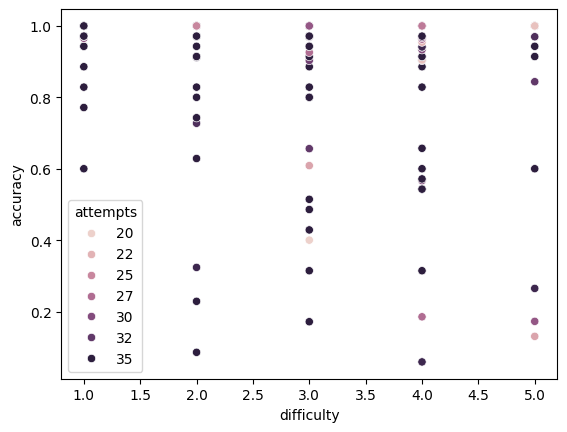

In [229]:
import seaborn as sns
sns.scatterplot(data=per_problem, x='difficulty', y='accuracy', hue='attempts')

In [230]:
per_problem.describe()

,accuracy,attempts,difficulty
count,144.000000,144.000000,144.000000
mean,0.859937,33.451389,2.854167
std,0.234649,3.262051,1.182440
min,0.058824,20.000000,1.000000
25%,0.828571,34.000000,2.000000
50%,0.971429,35.000000,3.000000
75%,1.000000,35.000000,4.000000
max,1.000000,35.000000,5.000000


Saved projection_margin_vs_pc1_by_difficulty.png


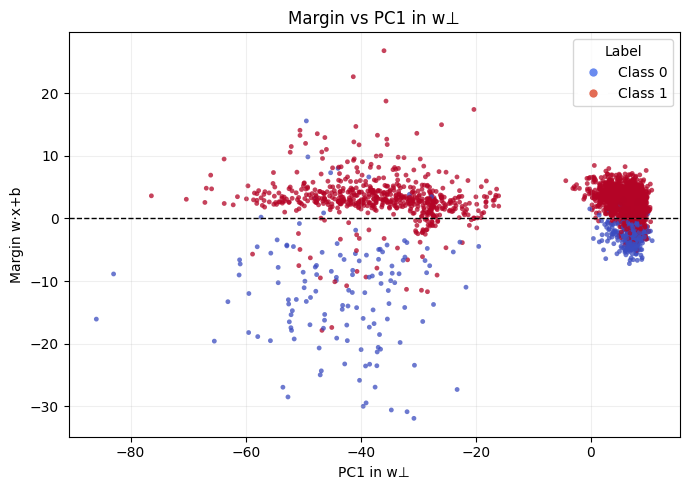

In [441]:
# Demo: Margin vs PC1 in w⊥ colored by difficulty
# Requires: plane (with w,b), X, y, and rollouts_token_df in scope
try:
    ax = plot_margin_vs_pc1_perp(
        X, y, plane["w"], plane["b"],
        # hue=rollouts_token_df["difficulty"].to_numpy() if 'rollouts_token_df' in globals() else None,
        hue_names=None,
        uids=uids if 'uids' in globals() else None,
        savepath="projection_margin_vs_pc1_by.png"
    )
    print("Saved projection_margin_vs_pc1_by_difficulty.png")
except Exception as e:
    print("Plot demo failed:", e)


In [414]:
# Demo: Misclassified examples table with full responses
# Requires: model, X, y and rollouts_token_df
try:
    missed_df = get_misclassified_examples(
        model, X, y,
        meta_df=rollouts_token_df if 'rollouts_token_df' in globals() else None,
        columns=["problem_id","difficulty","answer_text","full_response","gold_answer"] if 'rollouts_token_df' in globals() else None,
        include_gold=True,
        uids=(uids if 'uids' in globals() else None),
        top_k=200,
        sort_by="abs_margin",
        savepath="misclassified_examples.csv"
    )
    print("Saved misclassified_examples.csv; showing head:")
    display(missed_df.head(10))
except Exception as e:
    print("Misclassified examples demo failed:", e)


Saved misclassified_examples.csv; showing head:


,index,uid,y_true,y_pred,margin,prob_pos,problem_id,difficulty,answer_text,full_response,gold_answer
0,2637,testnumber_theory1032.json::testnumber_theory1...,1,0,-13.815510,1.734230e-08,testnumber_theory1032.json,3,2220,<think>\nTo solve the problem of finding the l...,2220
1,2640,testnumber_theory1032.json::testnumber_theory1...,1,0,-13.815510,2.738635e-08,testnumber_theory1032.json,3,2220,<think>\nTo determine the smallest positive mu...,2220
2,1578,testcounting_and_probability134.json::testcoun...,0,1,13.815510,9.999999e-01,testcounting_and_probability134.json,4,240,"<think>\nOkay, so I have this problem where I ...",720
3,4020,testprealgebra1804.json::testprealgebra1804.js...,1,0,-11.702289,8.274791e-06,testprealgebra1804.json,3,29,"<think>\nOkay, so I need to find the median nu...",29
4,2332,testintermediate_algebra1410.json::testinterme...,1,0,-11.470660,1.043160e-05,testintermediate_algebra1410.json,2,\dfrac{6}{5},"<think>\nOkay, so I've got this problem here w...",\frac65
5,2464,testintermediate_algebra1994.json::testinterme...,1,0,-11.323456,1.208594e-05,testintermediate_algebra1994.json,5,p-q,"<think>\nOkay, so I have this problem where I ...",p - q
6,1385,testalgebra893.json::testalgebra893.json.pt::6,1,0,-10.756840,2.129877e-05,testalgebra893.json,4,-1,"<think>\nTo find the value of \( a + b \), I'l...",-1
7,4563,testprecalculus1303.json::testprecalculus1303....,1,0,-10.117116,4.038079e-05,testprecalculus1303.json,1,\sqrt{51},"<think>\nOkay, so I have this problem where I'...",\sqrt{51}
8,1872,testgeometry1140.json::testgeometry1140.json.p...,0,1,9.811104,9.999452e-01,testgeometry1140.json,5,\dfrac{480}{17},<think>\nI need to find the area of triangle A...,\frac{3840}{289}
9,1519,testcounting_and_probability1114.json::testcou...,1,0,-9.500820,7.478487e-05,testcounting_and_probability1114.json,4,\dfrac{11}{36},<think>\nTo determine the probability that the...,\frac{11}{36}


In [438]:
print(math_df[math_df['_san_id']=="testgeometry1140.json"].problem.iloc[0])

In triangle $ABC$, $AB = 17$, $AC = 8$, and $BC = 15$.  Let $D$ be the foot of the altitude from $C$ to $AB$.  Find the area of triangle $ACD$.


In [439]:
print(missed_df.iloc[8].full_response[:2200])

<think>
I need to find the area of triangle ACD in triangle ABC where AB is 17, AC is 8, and BC is 15. D is the foot of the altitude from C to AB.

First, I'll use the Pythagorean theorem to find the length of the altitude CD. Since triangle ABC is a right triangle when considering the altitude CD, I can apply the Pythagorean theorem in triangles ADC and BDC.

Starting with triangle ADC:
AC² + CD² = AD²
8² + CD² = AD²
64 + CD² = AD²

Next, for triangle BDC:
BC² + CD² = BD²
15² + CD² = BD²
225 + CD² = BD²

Since AD + BD equals AB, which is 17:
AD + BD = 17

Substituting the expressions for AD² and BD²:
sqrt(64 + CD²) + sqrt(225 + CD²) = 17

This equation seems complex to solve algebraically, so I'll consider an alternative approach by using the area of triangle ABC. The area can be calculated using Heron's formula.

Calculating the semi-perimeter:
s = (AB + BC + AC) / 2 = (17 + 15 + 8) / 2 = 20

Using Heron's formula:
Area = sqrt[s(s - AB)(s - BC)(s - AC)] = sqrt[20(20 - 17)(20 - 15)(20

In [442]:
from typing import Optional, Dict, Any
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def plot_margin_vs_pc2_perp(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    b: float = 0.0,
    *,
    center: bool = True,
    random_state: int = 42,
    hue: Optional[np.ndarray] = None,
    class_names: Optional[Dict[int, str]] = None,
    hue_names: Optional[Dict[Any, str]] = None,
    cmap: str = "coolwarm",
    figsize: tuple = (7, 5),
    savepath: Optional[str] = None,
    ax: Optional[Any] = None,
    uids: Optional[np.ndarray] = None,
    return_data: bool = False,
):
    """
    Plot margin versus the second principal direction orthogonal to a linear decision plane.
    Mirrors `plot_margin_vs_pc1_perp`, but uses PC2 within w^\perp for the x-axis.
    """
    X = np.asarray(X)
    y = np.asarray(y).astype(int)
    w = np.asarray(w).astype(float)
    assert X.ndim == 2 and w.ndim == 1 and X.shape[1] == w.shape[0], "X shape and w length must agree"

    # Compute margins
    margin = (X @ w) + float(b)

    # Project to w^perp and take 2D PCA, use PC2
    w_norm = w / (np.linalg.norm(w) + 1e-12)
    X_center = X - (X.mean(axis=0, keepdims=True) if center else 0.0)
    X_ortho = X_center - (X_center @ w_norm[:, None]) * w_norm[None, :]
    pca = PCA(n_components=2, random_state=random_state)
    Z2 = pca.fit_transform(X_ortho)
    pc2 = Z2[:, 1]

    # Prepare plotting
    import matplotlib as mpl
    fig, ax = (None, ax) if ax is not None else (plt.figure(figsize=figsize), plt.gca())
    cmap_obj = plt.get_cmap(cmap)

    # Coloring
    if hue is None:
        cvals = (y == 1).astype(int)
        ax.scatter(pc2, margin, c=cvals, cmap=cmap_obj, s=12, alpha=0.75, edgecolors="none")
        class_names = class_names or {0: "Class 0", 1: "Class 1"}
        proxy0 = mpl.lines.Line2D([0],[0], marker='o', color='w', label=class_names.get(0,'0'),
                                  markerfacecolor=cmap_obj(0.15), markersize=7)
        proxy1 = mpl.lines.Line2D([0],[0], marker='o', color='w', label=class_names.get(1,'1'),
                                  markerfacecolor=cmap_obj(0.85), markersize=7)
        ax.legend(handles=[proxy0, proxy1], title="Label", loc="best", frameon=True)
    else:
        import pandas as pd  # ensure available at call time
        hue = np.asarray(hue)
        unique_vals = pd.unique(hue)
        import matplotlib as mpl
        norm = mpl.colors.Normalize(vmin=0, vmax=max(len(unique_vals)-1, 1))
        col_map = {val: plt.get_cmap(cmap)(norm(i)) for i, val in enumerate(unique_vals)}
        colors = np.array([col_map[v] for v in hue])
        ax.scatter(pc2, margin, c=colors, s=12, alpha=0.75, edgecolors="none")
        hue_names = hue_names or {}
        proxies = [mpl.lines.Line2D([0],[0], marker='o', color='w', markerfacecolor=col_map[val],
                                    markersize=7, label=hue_names.get(val, str(val)))
                   for val in unique_vals]
        ax.legend(handles=proxies, title="Group", loc="best", frameon=True)

    ax.axhline(0.0, color="k", linestyle="--", linewidth=1.0)
    ax.set_xlabel("PC2 in w⊥")
    ax.set_ylabel("Margin w⋅x+b")
    ax.set_title("Margin vs PC2 in w⊥")
    ax.grid(True, alpha=0.2)

    if savepath:
        fig = ax.figure
        fig.tight_layout()
        fig.savefig(savepath, dpi=160)

    if return_data:
        return {"pc2": pc2, "margin": margin, "indices": np.arange(X.shape[0]), "uids": (None if uids is None else np.asarray(uids))}
    return ax


def plot_margin_vs_pc12_3d_perp(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    b: float = 0.0,
    *,
    center: bool = True,
    random_state: int = 42,
    hue: Optional[np.ndarray] = None,
    class_names: Optional[Dict[int, str]] = None,
    hue_names: Optional[Dict[Any, str]] = None,
    cmap: str = "coolwarm",
    figsize: tuple = (8, 6),
    savepath: Optional[str] = None,
    ax: Optional[Any] = None,
    uids: Optional[np.ndarray] = None,
    return_data: bool = False,
):
    """
    3D scatter: PC1 (x) vs PC2 (y) vs margin (z) in the subspace orthogonal to w.
    Adds a translucent plane at margin=0 as a visual decision boundary.
    """
    X = np.asarray(X)
    y = np.asarray(y).astype(int)
    w = np.asarray(w).astype(float)
    assert X.ndim == 2 and w.ndim == 1 and X.shape[1] == w.shape[0], "X shape and w length must agree"

    margin = (X @ w) + float(b)

    # Project to w^perp and take 2D PCA
    w_norm = w / (np.linalg.norm(w) + 1e-12)
    X_center = X - (X.mean(axis=0, keepdims=True) if center else 0.0)
    X_ortho = X_center - (X_center @ w_norm[:, None]) * w_norm[None, :]
    pca = PCA(n_components=2, random_state=random_state)
    Z2 = pca.fit_transform(X_ortho)
    pc1 = Z2[:, 0]
    pc2 = Z2[:, 1]

    # Prepare 3D axes
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (ensures 3D projection is registered)
    import matplotlib as mpl
    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig = ax.figure

    cmap_obj = plt.get_cmap(cmap)

    # Coloring
    if hue is None:
        cvals = (y == 1).astype(int)
        sc = ax.scatter(pc1, pc2, margin, c=cvals, cmap=cmap_obj, s=10, alpha=0.75, depthshade=True)
        class_names = class_names or {0: "Class 0", 1: "Class 1"}
        proxy0 = mpl.lines.Line2D([0],[0], marker='o', color='w', label=class_names.get(0,'0'),
                                  markerfacecolor=cmap_obj(0.15), markersize=7)
        proxy1 = mpl.lines.Line2D([0],[0], marker='o', color='w', label=class_names.get(1,'1'),
                                  markerfacecolor=cmap_obj(0.85), markersize=7)
        ax.legend(handles=[proxy0, proxy1], title="Label", loc="best", frameon=True)
    else:
        import pandas as pd
        hue = np.asarray(hue)
        unique_vals = pd.unique(hue)
        norm = mpl.colors.Normalize(vmin=0, vmax=max(len(unique_vals)-1, 1))
        col_map = {val: cmap_obj(norm(i)) for i, val in enumerate(unique_vals)}
        colors = np.array([col_map[v] for v in hue])
        sc = ax.scatter(pc1, pc2, margin, c=colors, s=10, alpha=0.8, depthshade=True)
        hue_names = hue_names or {}
        proxies = [mpl.lines.Line2D([0],[0], marker='o', color='w', markerfacecolor=col_map[val],
                                    markersize=7, label=hue_names.get(val, str(val)))
                   for val in unique_vals]
        ax.legend(handles=proxies, title="Group", loc="best", frameon=True)

    # Decision plane z=0 across PC ranges
    try:
        xlim = (np.nanmin(pc1), np.nanmax(pc1))
        ylim = (np.nanmin(pc2), np.nanmax(pc2))
        Xg, Yg = np.meshgrid(np.linspace(xlim[0], xlim[1], 2), np.linspace(ylim[0], ylim[1], 2))
        Zg = np.zeros_like(Xg)
        ax.plot_surface(Xg, Yg, Zg, color='k', alpha=0.10, linewidth=0, antialiased=False)
    except Exception:
        pass

    ax.set_xlabel("PC1 in w⊥")
    ax.set_ylabel("PC2 in w⊥")
    ax.set_zlabel("Margin w⋅x+b")
    ax.set_title("3D: Margin vs (PC1, PC2) in w⊥")
    ax.view_init(elev=18, azim=-60)

    if savepath:
        fig.tight_layout()
        fig.savefig(savepath, dpi=160)

    if return_data:
        return {
            "pc1": pc1,
            "pc2": pc2,
            "margin": margin,
            "indices": np.arange(X.shape[0]),
            "uids": (None if uids is None else np.asarray(uids)),
        }
    return ax


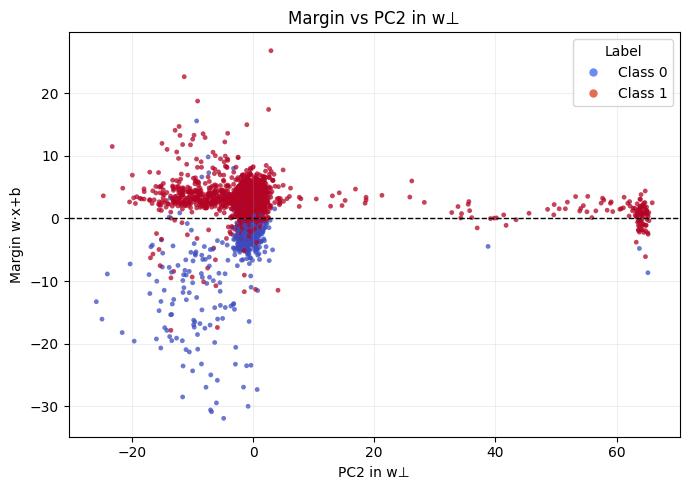

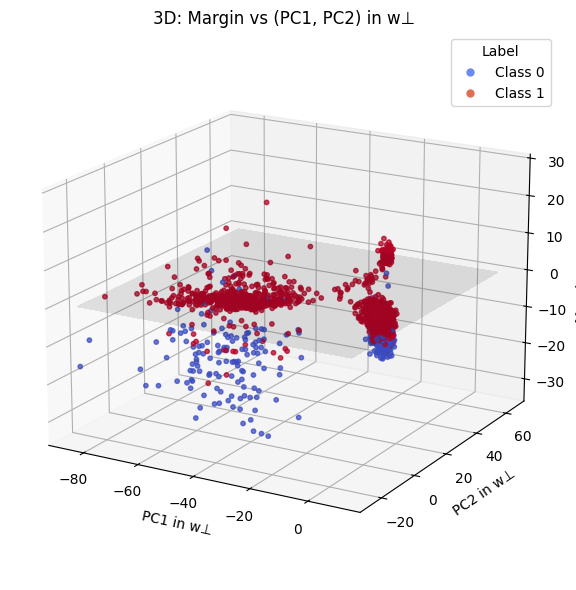

In [443]:
# 2D: Margin vs PC2 in w⊥
_ = plot_margin_vs_pc2_perp(X, y, plane["w"], plane["b"], savepath="projection_margin_vs_pc2.png")

# 3D: Margin vs PC1 vs PC2 in w⊥
_ = plot_margin_vs_pc12_3d_perp(X, y, plane["w"], plane["b"], savepath="projection_margin_vs_pc12_3d.png")

In [238]:
# CIs (effect size) and permutation p-values on the held-out test set
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score

def bootstrap_ci_scores(y, s, metric_fn, n_boot=5000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y)
    stats = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        stats[b] = metric_fn(y[idx], s[idx])
    lo, hi = np.quantile(stats, [alpha/2, 1 - alpha/2])
    return float(lo), float(hi)

def permutation_test_scores(y, s, metric_fn, n_perm=10000, seed=0, tail="right"):
    rng = np.random.default_rng(seed)
    obs = metric_fn(y, s)
    null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        y_perm = rng.permutation(y)
        null[i] = metric_fn(y_perm, s)
    if tail == "right":
        p = (1 + np.sum(null >= obs)) / (1 + n_perm)
    elif tail == "left":
        p = (1 + np.sum(null <= obs)) / (1 + n_perm)
    else:
        p = (1 + np.sum(np.abs(null - np.mean(null)) >= np.abs(obs - np.mean(null)))) / (1 + n_perm)
    return float(obs), float(p), null

# Unpack artifacts from your training call:
# model, metrics, eval_artifacts, plane, projection = train_linear_probe(...)
X_te, y_te, prob_te, pred_te = eval_artifacts

# Point estimates
auroc = roc_auc_score(y_te, prob_te)
auprc = average_precision_score(y_te, prob_te)
acc   = accuracy_score(y_te, pred_te)
f1    = f1_score(y_te, pred_te)

# 95% bootstrap CIs
auroc_ci = bootstrap_ci_scores(y_te, prob_te, roc_auc_score, n_boot=5000, alpha=0.05, seed=1)
auprc_ci = bootstrap_ci_scores(y_te, prob_te, average_precision_score, n_boot=5000, alpha=0.05, seed=1)
acc_ci   = bootstrap_ci_scores(y_te, pred_te, accuracy_score, n_boot=5000, alpha=0.05, seed=1)
f1_ci    = bootstrap_ci_scores(y_te, pred_te, f1_score, n_boot=5000, alpha=0.05, seed=1)

# Permutation p-values (fixed-model, right-tailed)
obs_auroc, p_auroc, _ = permutation_test_scores(y_te, prob_te, roc_auc_score, n_perm=10000, seed=2, tail="right")
obs_auprc, p_auprc, _ = permutation_test_scores(y_te, prob_te, average_precision_score, n_perm=10000, seed=2, tail="right")

print(f"AUROC = {auroc:.3f}  95% CI [{auroc_ci[0]:.3f}, {auroc_ci[1]:.3f}]  p_perm={p_auroc:.3g}")
print(f"AUPRC = {auprc:.3f}  95% CI [{auprc_ci[0]:.3f}, {auprc_ci[1]:.3f}]  p_perm={p_auprc:.3g}")
print(f"Acc   = {acc:.3f}    95% CI [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]")
print(f"F1    = {f1:.3f}     95% CI [{f1_ci[0]:.3f}, {f1_ci[1]:.3f}]")

AUROC = 0.854  95% CI [0.814, 0.891]  p_perm=0.0001
AUPRC = 0.959  95% CI [0.939, 0.977]  p_perm=0.0001
Acc   = 0.856    95% CI [0.834, 0.878]
F1    = 0.913     95% CI [0.899, 0.927]


In [239]:
def stratified_bootstrap_ci(y, s, metric_fn, n_boot=5000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y)
    stats = np.empty(n_boot, dtype=float)
    
    # Separate indices by class
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    
    for b in range(n_boot):
        # Resample within each class to preserve imbalance
        pos_sample = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        neg_sample = rng.choice(neg_idx, size=len(neg_idx), replace=True)
        all_idx = np.concatenate([pos_sample, neg_sample])
        
        stats[b] = metric_fn(y[all_idx], s[all_idx])
    
    lo, hi = np.quantile(stats, [alpha/2, 1 - alpha/2])
    return float(lo), float(hi)

# Recompute CIs with stratified bootstrap
auroc_ci_strat = stratified_bootstrap_ci(y_te, prob_te, roc_auc_score, n_boot=5000, alpha=0.05, seed=1)
auprc_ci_strat = stratified_bootstrap_ci(y_te, prob_te, average_precision_score, n_boot=5000, alpha=0.05, seed=1)
acc_ci_strat   = stratified_bootstrap_ci(y_te, pred_te, accuracy_score, n_boot=5000, alpha=0.05, seed=1)
f1_ci_strat    = stratified_bootstrap_ci(y_te, pred_te, f1_score, n_boot=5000, alpha=0.05, seed=1)

print("Stratified bootstrap CIs (preserves class imbalance):")
print(f"AUROC = {auroc:.3f}  95% CI [{auroc_ci_strat[0]:.3f}, {auroc_ci_strat[1]:.3f}]  p_perm={p_auroc:.3g}")
print(f"AUPRC = {auprc:.3f}  95% CI [{auprc_ci_strat[0]:.3f}, {auprc_ci_strat[1]:.3f}]  p_perm={p_auprc:.3g}")
print(f"Acc   = {acc:.3f}    95% CI [{acc_ci_strat[0]:.3f}, {acc_ci_strat[1]:.3f}]")
print(f"F1    = {f1:.3f}     95% CI [{f1_ci_strat[0]:.3f}, {f1_ci_strat[1]:.3f}]")

Stratified bootstrap CIs (preserves class imbalance):
AUROC = 0.854  95% CI [0.813, 0.890]  p_perm=0.0001
AUPRC = 0.959  95% CI [0.940, 0.975]  p_perm=0.0001
Acc   = 0.856    95% CI [0.834, 0.878]
F1    = 0.913     95% CI [0.899, 0.926]


Saved: projection_margin_vs_pc1_by_length.png, projection_margin_vs_pc2_by_length.png, projection_margin_vs_pc12_3d_by_length.png


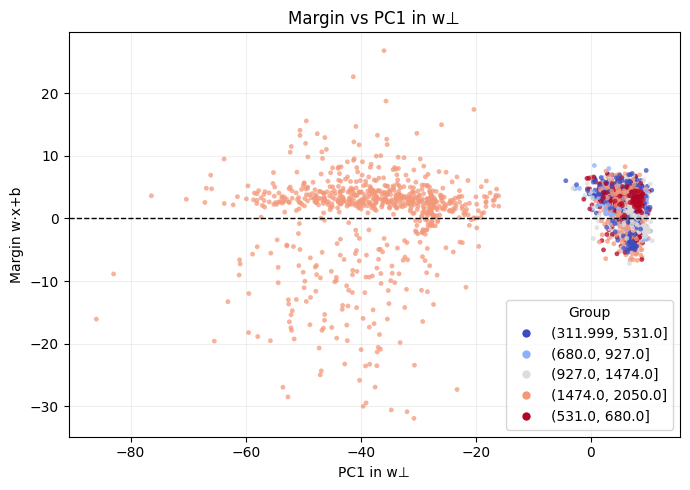

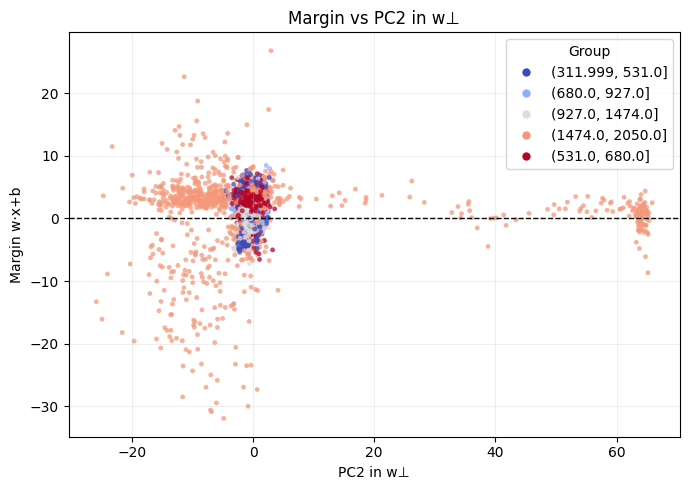

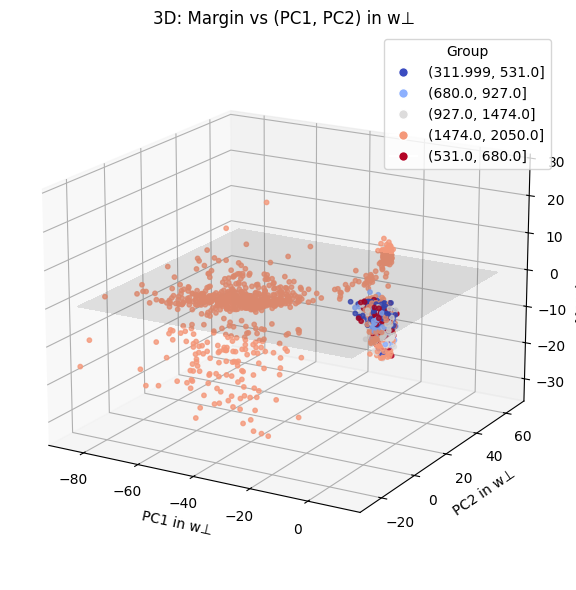

In [445]:
# Hue by response length: generate length-binned visualizations
import numpy as np
import pandas as pd

try:
    # Compute response length (prefer tokenizer-based token count; fallback to word count)
    if 'llm' in globals() and hasattr(llm, 'tokenizer') and llm.tokenizer is not None:
        resp_len = rollouts_token_df['full_response'].apply(
            lambda s: len(llm.tokenizer(s, add_special_tokens=False).input_ids)
        )
    else:
        # Fallback: word count
        resp_len = rollouts_token_df['full_response'].str.split().apply(len)
    # Bin lengths into quantiles for discrete hue groups
    len_bins = pd.qcut(resp_len, q=6,duplicates='drop')
    hue = len_bins.astype(str)
    hue_names = {s: s for s in sorted(pd.unique(hue))}

    # Ensure required artifacts exist
    assert 'X' in globals() and 'y' in globals(), "X/y not found in scope"
    assert 'plane' in globals() and plane is not None and 'w' in plane and 'b' in plane, "plane (w,b) not available"

    # 2D: Margin vs Invariant Direction 1 (PC1 in w⊥)
    _ = plot_margin_vs_pc1_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc1_by_length.png'
    )

    # 2D: Margin vs Invariant Direction 2 (PC2 in w⊥)
    _ = plot_margin_vs_pc2_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc2_by_length.png'
    )

    # 3D: Margin vs Invariant Directions 1 and 2
    _ = plot_margin_vs_pc12_3d_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc12_3d_by_length.png'
    )

    print('Saved: projection_margin_vs_pc1_by_length.png, projection_margin_vs_pc2_by_length.png, projection_margin_vs_pc12_3d_by_length.png')
except Exception as e:
    print('Length-hue plotting failed:', e)


Spearman(margin, length):  r=-0.097, p=1.36e-11
Spearman(PC1⊥, length):    r=-0.377, p=4.02e-162
Spearman(PC2⊥, length):    r=-0.093, p=8.1e-11


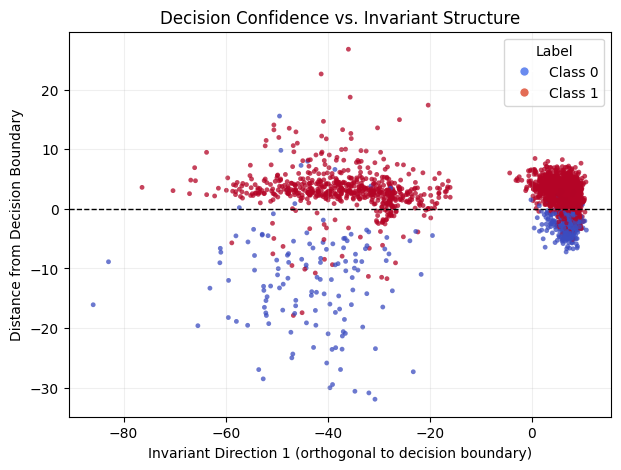

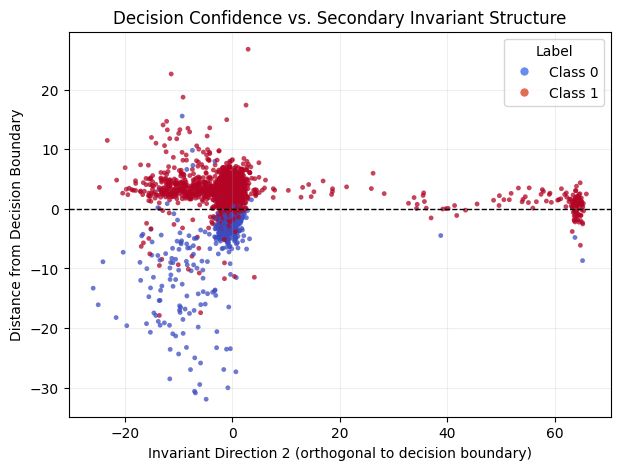

In [253]:
# Spearman correlations between response length and margin/PC1/PC2
import numpy as np
import pandas as pd

from scipy.stats import spearmanr



# Response length (prefer tokenizer tokens; fallback to word count)
if 'llm' in globals() and hasattr(llm, 'tokenizer') and llm.tokenizer is not None:
    resp_len = rollouts_token_df['full_response'].apply(
        lambda s: len(llm.tokenizer(s, add_special_tokens=False).input_ids)
    ).to_numpy()
else:
    resp_len = rollouts_token_df['full_response'].str.split().apply(len).to_numpy()

# Required artifacts
assert 'X' in globals() and 'y' in globals(), "X/y not found"
assert 'plane' in globals() and plane is not None and 'w' in plane and 'b' in plane, "plane (w,b) missing"

w = plane['w'].astype(float)
b = float(plane['b'])

# Margin and orthogonal PCs
margin = X @ w + b
pc1_data = plot_margin_vs_pc1_perp(X, y, w, b, return_data=True)
pc2_data = plot_margin_vs_pc2_perp(X, y, w, b, return_data=True)
pc1 = pc1_data['pc1']
pc2 = pc2_data['pc2']

def spearman_safe(a, b):
    if spearmanr is not None:
        r, p = spearmanr(a, b)
        return float(r), float(p)

r_m_len, p_m_len = spearman_safe(margin, resp_len)
r_pc1_len, p_pc1_len = spearman_safe(pc1, resp_len)
r_pc2_len, p_pc2_len = spearman_safe(pc2, resp_len)

print(f"Spearman(margin, length):  r={r_m_len:.3f}, p={p_m_len:.3g}")
print(f"Spearman(PC1⊥, length):    r={r_pc1_len:.3f}, p={p_pc1_len:.3g}")
print(f"Spearman(PC2⊥, length):    r={r_pc2_len:.3f}, p={p_pc2_len:.3g}")




Saved: projection_margin_vs_pc1_by_difficulty.png, projection_margin_vs_pc2_by_difficulty.png, projection_margin_vs_pc12_3d_by_difficulty.png
Spearman(margin, difficulty): r=-0.146, p=3.24e-24
Spearman(PC1⊥, difficulty):   r=-0.163, p=4.7e-30
Spearman(PC2⊥, difficulty):   r=-0.028, p=0.049


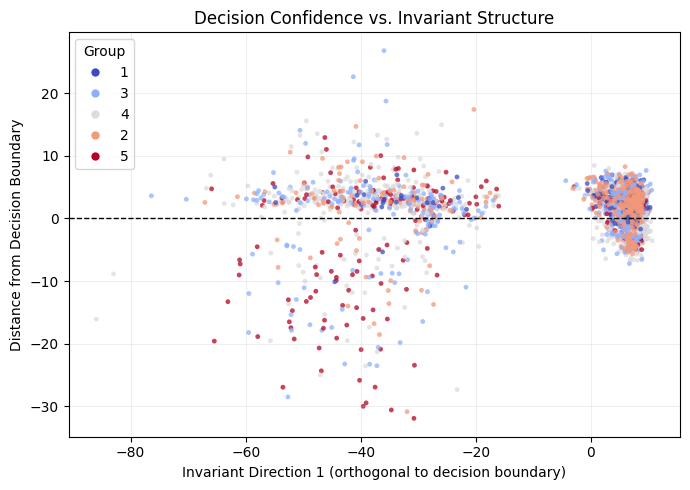

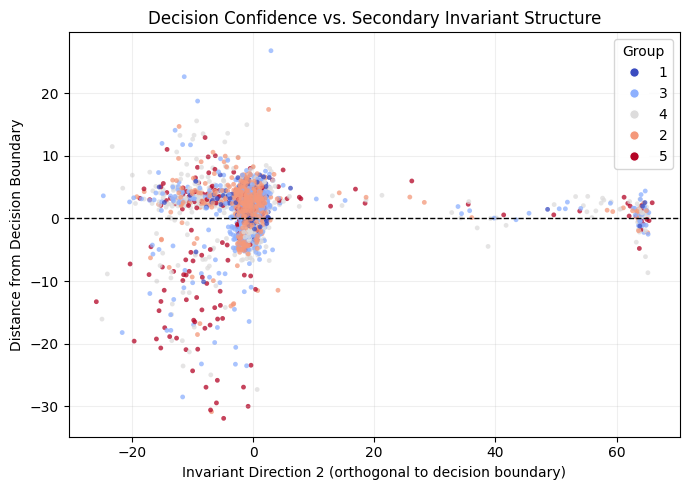

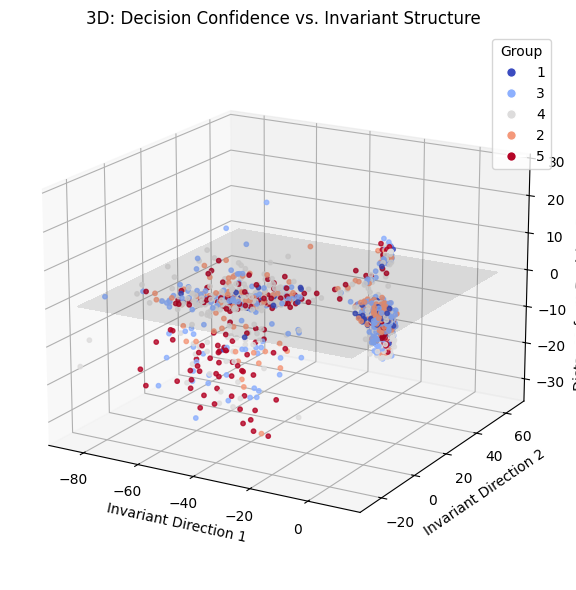

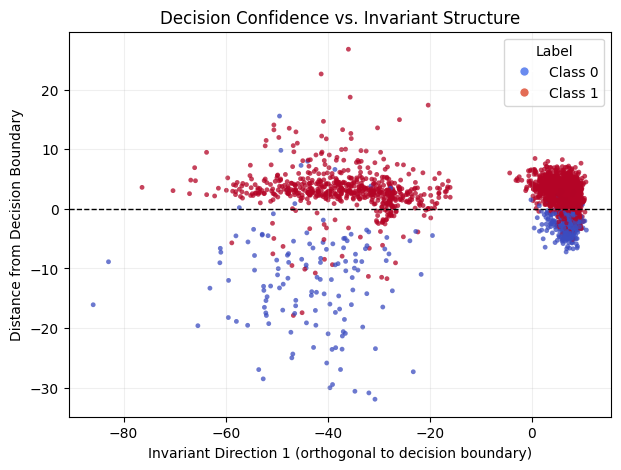

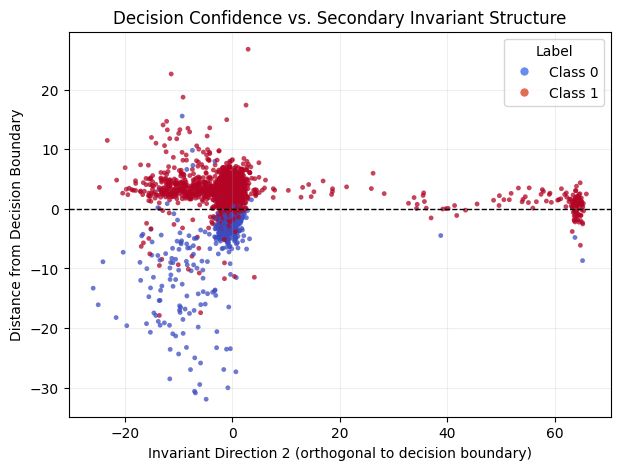

In [257]:
# Hue by difficulty + Spearman correlations vs difficulty
import numpy as np
import pandas as pd

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

try:
    # Ensure required artifacts
    assert 'rollouts_token_df' in globals(), "rollouts_token_df not found"
    assert 'X' in globals() and 'y' in globals(), "X/y not found"
    assert 'plane' in globals() and plane is not None and 'w' in plane and 'b' in plane, "plane (w,b) not available"

    # Difficulty as hue (categorical)
    diff_series = rollouts_token_df['difficulty'].astype(str)
    hue = diff_series.to_numpy()
    hue_names = {v: v for v in pd.unique(diff_series)}

    # Plots colored by difficulty
    _ = plot_margin_vs_pc1_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc1_by_difficulty.png'
    )
    _ = plot_margin_vs_pc2_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc2_by_difficulty.png'
    )
    _ = plot_margin_vs_pc12_3d_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc12_3d_by_difficulty.png'
    )

    # Ordinal encoding for difficulty for Spearman
    def encode_difficulty_ordinal(s: pd.Series) -> np.ndarray:
        # Try extracting integers like 'Level 3' -> 3
        import re
        nums = s.str.extract(r"(\d+)")[0]
        if nums.notna().any():
            # If extraction works for a majority, use it
            vals = pd.to_numeric(nums, errors='coerce')
            if vals.notna().sum() >= 0.6 * len(vals):
                # Fill remaining with rank codes
                fill_codes = s[vals.isna()]
                if not fill_codes.empty:
                    cat_codes = pd.Categorical(fill_codes).codes
                    vals.loc[vals.isna()] = cat_codes
                return vals.to_numpy(dtype=float)
        # Fallback: alphabetical category codes as an ordinal proxy
        return pd.Categorical(s).codes.astype(float)

    diff_ord = encode_difficulty_ordinal(diff_series)

    # Compute PCs (orthogonal)
    w = plane['w'].astype(float)
    b = float(plane['b'])
    margin = X @ w + b
    pc1 = plot_margin_vs_pc1_perp(X, y, w, b, return_data=True)['pc1']
    pc2 = plot_margin_vs_pc2_perp(X, y, w, b, return_data=True)['pc2']

    def spearman_safe(a, b):
        if spearmanr is not None:
            r, p = spearmanr(a, b)
            return float(r), float(p)
        ar = pd.Series(a).rank(method='average').to_numpy()
        br = pd.Series(b).rank(method='average').to_numpy()
        r = np.corrcoef(ar, br)[0, 1]
        return float(r), float('nan')

    r_m_d, p_m_d = spearman_safe(margin, diff_ord)
    r_pc1_d, p_pc1_d = spearman_safe(pc1, diff_ord)
    r_pc2_d, p_pc2_d = spearman_safe(pc2, diff_ord)

    print('Saved: projection_margin_vs_pc1_by_difficulty.png, projection_margin_vs_pc2_by_difficulty.png, projection_margin_vs_pc12_3d_by_difficulty.png')
    print(f"Spearman(margin, difficulty): r={r_m_d:.3f}, p={p_m_d:.3g}")
    print(f"Spearman(PC1⊥, difficulty):   r={r_pc1_d:.3f}, p={p_pc1_d:.3g}")
    print(f"Spearman(PC2⊥, difficulty):   r={r_pc2_d:.3f}, p={p_pc2_d:.3g}")
except Exception as e:
    print('Difficulty-hue and Spearman failed:', e)


In [259]:
# Spearman correlation between margin and label (binary)
import numpy as np
import pandas as pd

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

try:
    assert 'X' in globals() and 'y' in globals(), "X/y not found"
    assert 'plane' in globals() and plane is not None and 'w' in plane and 'b' in plane, "plane (w,b) missing"

    w = plane['w'].astype(float)
    b = float(plane['b'])
    margin = X @ w + b

    def spearman_safe(a, b):
        if spearmanr is not None:
            r, p = spearmanr(a, b)
            return float(r), float(p)
        ar = pd.Series(a).rank(method='average').to_numpy()
        br = pd.Series(b).rank(method='average').to_numpy()
        r = np.corrcoef(ar, br)[0, 1]
        return float(r), float('nan')

    r_ml, p_ml = spearman_safe(margin, y.astype(float))
    print(f"Spearman(margin, label): r={r_ml:.3f}, p={p_ml:.3g}")
except Exception as e:
    print('Spearman(margin, label) failed:', e)


Spearman(margin, label): r=0.553, p=0


Saved subject-hued plots. Subject counts: {'Algebra': 1476, 'Prealgebra': 1102, 'Number Theory': 765, 'Intermediate Algebra': 463, 'Counting & Probability': 382, 'Precalculus': 332, 'Geometry': 297}


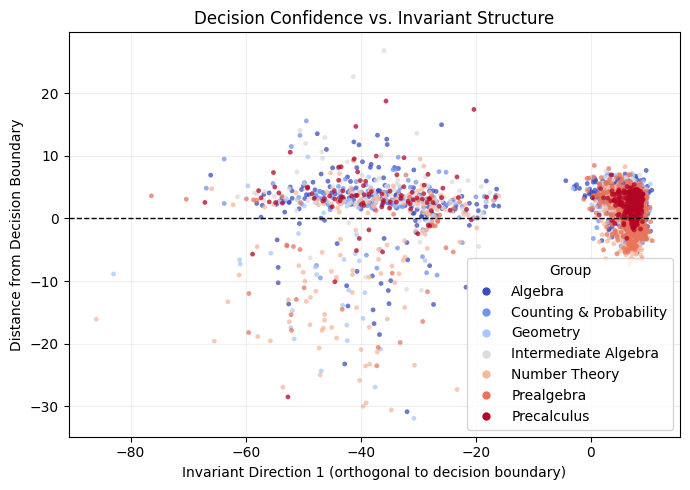

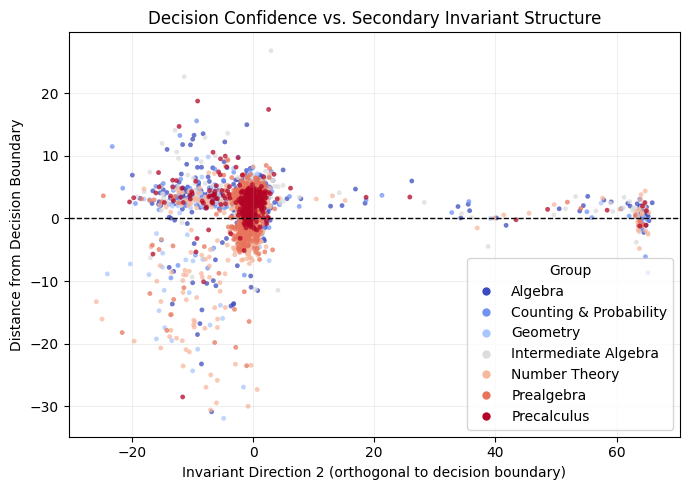

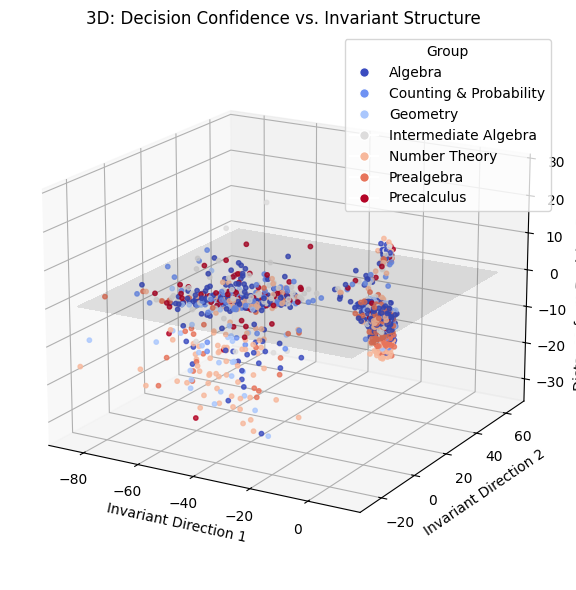

In [263]:
# Hue by subject (from math_df) and plots
import numpy as np
import pandas as pd

try:
    assert 'rollouts_token_df' in globals(), "rollouts_token_df not found"
    assert 'math_df' in globals(), "math_df not found"
    assert 'X' in globals() and 'y' in globals(), "X/y not found"
    assert 'plane' in globals() and plane is not None and 'w' in plane and 'b' in plane, "plane (w,b) not available"

    if 'subject' not in math_df.columns:
        raise KeyError("math_df has no 'subject' column")

    # Ensure sanitized id exists on math_df
    if '_san_id' not in math_df.columns:
        math_df['_san_id'] = math_df['unique_id'].str.replace('/', '', regex=False)

    # Map subject onto rollouts by problem_id (which matches _san_id)
    subject_map = dict(zip(math_df['_san_id'], math_df['subject']))
    rollouts_token_df = rollouts_token_df.assign(
        subject=lambda df: df['problem_id'].map(subject_map).astype('object')
    )
    # Fill missing subjects if any
    rollouts_token_df['subject'] = rollouts_token_df['subject'].fillna('Unknown').astype(str)

    hue = rollouts_token_df['subject'].to_numpy()
    hue_names = {v: v for v in pd.unique(rollouts_token_df['subject'])}

    # Plots colored by subject
    _ = plot_margin_vs_pc1_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc1_by_subject.png'
    )
    _ = plot_margin_vs_pc2_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc2_by_subject.png'
    )
    _ = plot_margin_vs_pc12_3d_perp(
        X, y, plane['w'], plane['b'], hue=hue, hue_names=hue_names,
        savepath='projection_margin_vs_pc12_3d_by_subject.png'
    )

    # Quick sanity
    counts = rollouts_token_df['subject'].value_counts().to_dict()
    print('Saved subject-hued plots. Subject counts:', counts)
except Exception as e:
    print('Subject-hue plotting failed:', e)


In [264]:
# One-way ANOVA: Does subject explain variance in margin?
import numpy as np
import pandas as pd

try:
    from scipy.stats import f_oneway
except Exception:
    f_oneway = None

try:
    # Preconditions
    assert 'rollouts_token_df' in globals(), "rollouts_token_df not found"
    assert 'X' in globals() and 'y' in globals(), "X/y not found"
    assert 'plane' in globals() and plane is not None and 'w' in plane and 'b' in plane, "plane (w,b) not available"

    # Ensure subject exists; if not, attempt to build from math_df
    if 'subject' not in rollouts_token_df.columns:
        if 'math_df' not in globals():
            raise RuntimeError("'subject' not in rollouts_token_df and math_df not available to map it.")
        if '_san_id' not in math_df.columns:
            math_df['_san_id'] = math_df['unique_id'].str.replace('/', '', regex=False)
        subject_map = dict(zip(math_df['_san_id'], math_df['subject']))
        rollouts_token_df = rollouts_token_df.assign(
            subject=lambda df: df['problem_id'].map(subject_map).fillna('Unknown').astype(str)
        )

    w = plane['w'].astype(float)
    b = float(plane['b'])
    margin = (X @ w + b).astype(float)

    subject = rollouts_token_df['subject'].astype(str).to_numpy()
    cats = pd.unique(subject)

    # Group margins by subject; drop groups with <2 samples (ANOVA requirement)
    groups = []
    kept = []
    dropped = []
    for c in cats:
        vals = margin[subject == c]
        if vals.size >= 2:
            groups.append(vals)
            kept.append(c)
        else:
            dropped.append(c)

    if len(groups) < 2:
        raise RuntimeError("Not enough groups with >=2 samples for ANOVA.")

    # Compute classical one-way ANOVA
    if f_oneway is not None:
        F_stat, p_val = f_oneway(*groups)
    else:
        # Manual F (rare fallback)
        all_vals = np.concatenate(groups)
        overall_mean = float(all_vals.mean())
        ns = np.array([g.size for g in groups], dtype=float)
        means = np.array([g.mean() for g in groups], dtype=float)
        SS_between = float(np.sum(ns * (means - overall_mean) ** 2))
        SS_total = float(np.sum((all_vals - overall_mean) ** 2))
        SS_within = SS_total - SS_between
        k = len(groups)
        N = int(ns.sum())
        MS_between = SS_between / (k - 1)
        MS_within = SS_within / (N - k)
        F_stat = MS_between / (MS_within + 1e-12)
        p_val = float('nan')

    # Effect sizes
    all_vals = np.concatenate(groups)
    overall_mean = float(all_vals.mean())
    ns = np.array([g.size for g in groups], dtype=float)
    means = np.array([g.mean() for g in groups], dtype=float)
    SS_between = float(np.sum(ns * (means - overall_mean) ** 2))
    SS_total = float(np.sum((all_vals - overall_mean) ** 2))
    SS_within = SS_total - SS_between
    k = len(groups)
    N = int(ns.sum())
    MS_within = SS_within / max(N - k, 1)

    eta_sq = SS_between / (SS_total + 1e-12)
    omega_sq = (SS_between - (k - 1) * MS_within) / (SS_total + MS_within + 1e-12)

    # Print summary
    print("ANOVA (margin ~ subject)")
    print(f"Groups kept: {len(kept)}; dropped (<2 samples): {len(dropped)}")
    if dropped:
        print("Dropped:", sorted(dropped)[:10], ("..." if len(dropped) > 10 else ""))
    print(f"F = {F_stat:.3f}, p = {p_val:.3g}")
    print(f"eta^2 = {eta_sq:.4f}, omega^2 = {omega_sq:.4f}")

    # Optional per-group stats
    group_stats = pd.DataFrame({
        'subject': kept,
        'n': ns.astype(int),
        'mean_margin': means,
        'std_margin': np.array([g.std(ddof=1) if g.size > 1 else np.nan for g in groups], dtype=float),
    }).sort_values('n', ascending=False)
    group_stats.to_csv('anova_subject_group_stats.csv', index=False)
    print("Saved per-group stats to anova_subject_group_stats.csv")
except Exception as e:
    print('ANOVA failed:', e)


ANOVA (margin ~ subject)
Groups kept: 7; dropped (<2 samples): 0
F = 68.218, p = 9e-82
eta^2 = 0.0784, omega^2 = 0.0773
Saved per-group stats to anova_subject_group_stats.csv


Saved roc_pr_curves.png


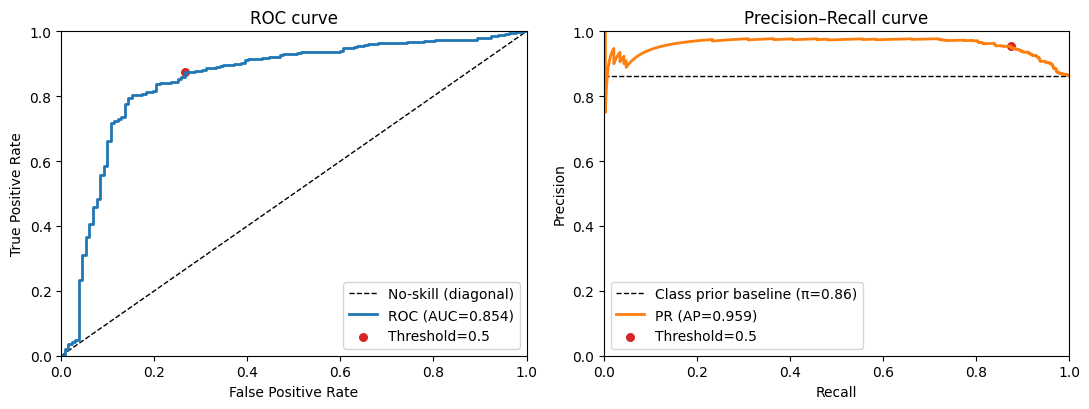

In [413]:
# ROC & PR curves with baselines; saves roc_pr_curves.png
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score
)

# Unpack your saved artifacts
X_te, y_te, prob_te, pred_te = eval_artifacts

# Metrics/curves
fpr, tpr, _ = roc_curve(y_te, prob_te)
prec, rec, _ = precision_recall_curve(y_te, prob_te)
roc_auc = roc_auc_score(y_te, prob_te)
ap = average_precision_score(y_te, prob_te)
prevalence = float(np.mean(y_te))  # baseline for PR

# Operating-point (threshold=0.5) markers
tp = int(np.sum((y_te == 1) & (pred_te == 1)))
fp = int(np.sum((y_te == 0) & (pred_te == 1)))
tn = int(np.sum((y_te == 0) & (pred_te == 0)))
fn = int(np.sum((y_te == 1) & (pred_te == 0)))
tpr_pt = tp / max(tp + fn, 1)
fpr_pt = fp / max(fp + tn, 1)
prec_pt = tp / max(tp + fp, 1)
rec_pt = tpr_pt

# Plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# ROC
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='No-skill (diagonal)')
ax.plot(fpr, tpr, color='C0', lw=2, label=f'ROC (AUC={roc_auc:.3f})')
ax.scatter([fpr_pt], [tpr_pt], color='C3', s=30, label='Threshold=0.5')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='lower right')

# PR
ax = axes[1]
ax.hlines(prevalence, 0, 1, colors='k', linestyles='--', lw=1,
          label=f'Class prior baseline (π={prevalence:.2f})')
ax.plot(rec, prec, color='C1', lw=2, label=f'PR (AP={ap:.3f})')
ax.scatter([rec_pt], [prec_pt], color='C3', s=30, label='Threshold=0.5')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall curve')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='lower left')

fig.tight_layout()
fig.savefig('roc_pr_curves.png', dpi=160)
print('Saved roc_pr_curves.png')


In [265]:
# Compute and save margin direction tensor; find hardest True Negative by plane
import numpy as np
import torch

try:
    assert 'X' in globals() and 'y' in globals(), "X/y not found"
    assert 'plane' in globals() and plane is not None and 'w' in plane and 'b' in plane, "plane (w,b) not available"
    # 1) Unit margin direction as torch tensor
    w_np = np.asarray(plane['w'], dtype=np.float32)
    w_unit = w_np / (np.linalg.norm(w_np) + 1e-12)
    margin_direction_t = torch.from_numpy(w_unit)

    # 2) Plane-based margin and predictions for all samples
    margins = (X @ plane['w'] + float(plane['b']))  # positive => class 1
    preds_plane = (margins >= 0).astype(np.int64)

    # 3) Hardest True Negative: y==0 and pred==0 with most negative margin
    tn_mask = (y.astype(np.int64) == 0) & (preds_plane == 0)
    if not np.any(tn_mask):
        hardest_tn_index = None
        hardest_tn_margin = None
    else:
        tn_indices = np.where(tn_mask)[0]
        hardest_tn_index = int(tn_indices[np.argmin(margins[tn_indices])])
        hardest_tn_margin = float(margins[hardest_tn_index])

    # 4) Save just the tensor for downstream use
    torch.save(margin_direction_t, 'margin_direction_t.pt')
    print('Saved margin_direction_t.pt')
    print('Hardest TN index:', hardest_tn_index, 'margin:', hardest_tn_margin)
except Exception as e:
    print('Saving margin direction tensor failed:', e)


Saved margin_direction_t.pt
Hardest TN index: 1879 margin: -31.91716106476737


In [266]:
rollouts_token_df.iloc[1879]

uid              testgeometry1140.json::testgeometry1140.json.p...
problem_id                                   testgeometry1140.json
full_response    <think>\nI need to find the area of triangle A...
think            \nI need to find the area of triangle ACD in t...
answer_text                                        \dfrac{480}{17}
hidden           [0.34765625, -0.76953125, 0.84375, 0.125, -0.4...
file                                      testgeometry1140.json.pt
seq_index                                                       22
gold_answer                                       \frac{3840}{289}
difficulty                                                       5
label                                                            0
subject                                                   Geometry
Name: 1879, dtype: object

In [267]:
torch.load('margin_direction_t.pt')

tensor([-0.0093,  0.0056, -0.0201,  ..., -0.0231,  0.0076,  0.0080])

In [286]:
# Fix dimensions for cosine similarity
margin_dir = torch.load('margin_direction_t.pt')
sample_tensor = torch.from_numpy(X[1879])

# Ensure both tensors are 1D and compute cosine similarity
torch.cosine_similarity(margin_dir.unsqueeze(0), sample_tensor.unsqueeze(0), dim=-1)

tensor([-0.0608])

In [256]:
resp_len

array([466, 466, 466, ..., 567, 567, 567], shape=(4817,))

In [293]:
probem_text=math_df[math_df['_san_id'] == 'testgeometry1140.json'].problem.iloc[0]

In [287]:
from nnsight import CONFIG
CONFIG.API.APIKEY = "c082b87e-d32b-426f-961f-bd636a711885"

In [308]:
llm.tokenizer.encode(rollouts_token_df.iloc[1879].full_response,add_special_tokens=False)

[128013,
 198,
 40,
 1205,
 311,
 1505,
 279,
 3158,
 315,
 22217,
 362,
 6620,
 304,
 22217,
 19921,
 1405,
 14469,
 374,
 220,
 1114,
 11,
 10807,
 374,
 220,
 23,
 11,
 323,
 18531,
 374,
 220,
 868,
 13,
 423,
 374,
 279,
 4579,
 315,
 279,
 36958,
 505,
 1486,
 356,
 311,
 14469,
 382,
 5451,
 11,
 358,
 3358,
 11294,
 279,
 3158,
 315,
 22217,
 19921,
 1701,
 6385,
 263,
 596,
 15150,
 13,
 578,
 18768,
 17453,
 26402,
 320,
 82,
 8,
 374,
 320,
 1114,
 489,
 220,
 868,
 489,
 220,
 23,
 8,
 611,
 220,
 17,
 11,
 902,
 374,
 220,
 508,
 13,
 5112,
 11,
 279,
 3158,
 374,
 18430,
 12144,
 1161,
 482,
 14469,
 2432,
 82,
 482,
 18531,
 2432,
 82,
 482,
 10807,
 7400,
 284,
 18430,
 58,
 508,
 7,
 508,
 482,
 220,
 1114,
 2432,
 508,
 482,
 220,
 868,
 2432,
 508,
 482,
 220,
 23,
 7400,
 284,
 18430,
 58,
 508,
 353,
 220,
 18,
 353,
 220,
 20,
 353,
 220,
 717,
 60,
 284,
 18430,
 58,
 13104,
 15,
 60,
 284,
 220,
 1399,
 382,
 5971,
 11,
 358,
 3358,
 1505,
 279,
 3160,
 315,
 27

In [ ]:
probem_text=math_df[math_df['_san_id'] == 'testgeometry1140.json'].problem.iloc[0]
system_instructions = f"Solve the following math problem. Enclose your thoughts within <think>\n\n</think> tags. Your final answer should be denoted as **Answer:** and must be enclosed in \\boxed{{}}"
chat = [
    {"role": "user", "content": f"{system_instructions}\n\nProblem: {problem_text}"},
]
prompt = llm.tokenizer.apply_chat_template(chat, tokenize=True, add_generation_prompt=True)

In [298]:
problem_text=math_df[math_df['_san_id'] == 'testgeometry1140.json'].problem.iloc[0]
print(problem_text)

In triangle $ABC$, $AB = 17$, $AC = 8$, and $BC = 15$.  Let $D$ be the foot of the altitude from $C$ to $AB$.  Find the area of triangle $ACD$.


In [302]:
prompt[:-2]+llm.tokenizer.encode(rollouts_token_df.iloc[1879].full_response,add_special_tokens=False)

[128000,
 128011,
 50,
 4035,
 279,
 2768,
 7033,
 3575,
 13,
 10984,
 1497,
 701,
 11555,
 2949,
 220,
 128013,
 271,
 128014,
 9681,
 13,
 4718,
 1620,
 4320,
 1288,
 387,
 3453,
 9437,
 439,
 3146,
 16533,
 68063,
 323,
 2011,
 387,
 44910,
 304,
 1144,
 80175,
 32583,
 32298,
 25,
 763,
 22217,
 400,
 26484,
 55976,
 400,
 1905,
 284,
 220,
 1114,
 55976,
 400,
 1741,
 284,
 220,
 23,
 55976,
 323,
 400,
 5002,
 284,
 220,
 868,
 13244,
 220,
 6914,
 400,
 35,
 3,
 387,
 279,
 4579,
 315,
 279,
 36958,
 505,
 400,
 34,
 3,
 311,
 400,
 1905,
 13244,
 220,
 7531,
 279,
 3158,
 315,
 22217,
 400,
 1741,
 35,
 13244,
 128012]

In [309]:
prompt[:-2]

[128000,
 128011,
 50,
 4035,
 279,
 2768,
 7033,
 3575,
 13,
 10984,
 1497,
 701,
 11555,
 2949,
 220,
 128013,
 271,
 128014,
 9681,
 13,
 4718,
 1620,
 4320,
 1288,
 387,
 3453,
 9437,
 439,
 3146,
 16533,
 68063,
 323,
 2011,
 387,
 44910,
 304,
 1144,
 80175,
 32583,
 32298,
 25,
 763,
 22217,
 400,
 26484,
 55976,
 400,
 1905,
 284,
 220,
 1114,
 55976,
 400,
 1741,
 284,
 220,
 23,
 55976,
 323,
 400,
 5002,
 284,
 220,
 868,
 13244,
 220,
 6914,
 400,
 35,
 3,
 387,
 279,
 4579,
 315,
 279,
 36958,
 505,
 400,
 34,
 3,
 311,
 400,
 1905,
 13244,
 220,
 7531,
 279,
 3158,
 315,
 22217,
 400,
 1741,
 35,
 13244,
 128012]

In [316]:
new_prompt=prompt[:-2]+llm.tokenizer.encode(rollouts_token_df.iloc[1879].full_response,add_special_tokens=False)

In [318]:
new_prompt=new_prompt[:850]

In [374]:
llm.tokenizer.decode(new_prompt[687])

'times'

In [398]:

with llm.trace(sample['token_batch'][-2],remote=True) as tracer:
    hidden_states=llm.model.layers[-1].output.save()

[2025-08-29 23:04:19] [4d5aadd0-be0f-4f1c-b4c0-3fe1cd1897dd] RECEIVED   : Your job has been received and is waiting to be queued.
[2025-08-29 23:04:19] [4d5aadd0-be0f-4f1c-b4c0-3fe1cd1897dd] QUEUED     : Your job has been recieved by the coordinator and is waiting to be queued.
[2025-08-29 23:04:19] [4d5aadd0-be0f-4f1c-b4c0-3fe1cd1897dd] QUEUED     : Task 4d5aadd0-be0f-4f1c-b4c0-3fe1cd1897dd has been added to the queue. Currently at position 1
[2025-08-29 23:04:19] [4d5aadd0-be0f-4f1c-b4c0-3fe1cd1897dd] QUEUED     : Dispatching task...
[2025-08-29 23:04:20] [4d5aadd0-be0f-4f1c-b4c0-3fe1cd1897dd] RUNNING    : Your job has started running.
[2025-08-29 23:04:21] [4d5aadd0-be0f-4f1c-b4c0-3fe1cd1897dd] COMPLETED  : Your job has been completed.


In [408]:
hidden_states[:,38*
,:]

tensor([[ 0.5430,  0.0320,  1.5312,  ..., -0.3945,  0.9688,  0.3516]],
       dtype=torch.bfloat16)

In [412]:
torch.cosine_similarity(hidden_states[:,388,:],margin_dir)

tensor([-0.0145])

In [365]:
hidden_states[:,280,:]

tensor([[ 0.4160,  1.6406, -0.4648,  ...,  0.6016, -0.0618, -0.0488]],
       dtype=torch.bfloat16)

In [363]:
sample_tensor

tensor([ 0.3477, -0.7695,  0.8438,  ...,  0.3320,  1.6641, -0.4492])

In [368]:
hidden_states[:,1:,:]-hidden_states[:,:-1,:]

tensor([[[-0.8594, -1.1250, -0.6641,  ...,  0.1348, -2.8281, -0.5938],
         [ 1.3047, -1.0000,  0.3809,  ...,  1.2812,  1.3906,  1.1797],
         [-1.3594,  1.5469, -0.3711,  ..., -0.8516,  0.0884, -1.4219],
         ...,
         [ 0.6016, -0.0117, -0.4668,  ...,  1.1953, -0.5234, -0.3359],
         [-0.3438, -0.6602,  1.1406,  ..., -0.5938,  0.9766, -2.2188],
         [-0.0703,  1.3516, -1.0312,  ..., -0.1250,  0.7344,  2.6875]]],
       dtype=torch.bfloat16)

In [380]:
sample=torch.load("rollouts/testgeometry1140.json.pt")

In [404]:
(sample['token_batch'][-2]==128014)


tensor([[ 17],
        [388]])

[128000,
 128011,
 50,
 4035,
 279,
 2768,
 7033,
 3575,
 13,
 10984,
 1497,
 701,
 11555,
 2949,
 220,
 128013,
 271,
 128014,
 9681,
 13,
 4718,
 1620,
 4320,
 1288,
 387,
 3453,
 9437,
 439,
 3146,
 16533,
 68063,
 323,
 2011,
 387,
 44910,
 304,
 1144,
 80175,
 32583,
 32298,
 25,
 763,
 22217,
 400,
 26484,
 55976,
 400,
 1905,
 284,
 220,
 1114,
 55976,
 400,
 1741,
 284,
 220,
 23,
 55976,
 323,
 400,
 5002,
 284,
 220,
 868,
 13244,
 220,
 6914,
 400,
 35,
 3,
 387,
 279,
 4579,
 315,
 279,
 36958,
 505,
 400,
 34,
 3,
 311,
 400,
 1905,
 13244,
 220,
 7531,
 279,
 3158,
 315,
 22217,
 400,
 1741,
 35,
 13244,
 128012,
 128013,
 198,
 40,
 1205,
 311,
 1505,
 279,
 3158,
 315,
 22217,
 362,
 6620,
 304,
 22217,
 19921,
 1405,
 14469,
 374,
 220,
 1114,
 11,
 10807,
 374,
 220,
 23,
 11,
 323,
 18531,
 374,
 220,
 868,
 13,
 423,
 374,
 279,
 4579,
 315,
 279,
 36958,
 505,
 1486,
 356,
 311,
 14469,
 382,
 5451,
 11,
 358,
 3358,
 11294,
 279,
 3158,
 315,
 22217,
 19921,
 1701